## __Data Science: Capstone Part 2: Lightning Talk 2__

### Overview

On the **One** topic you have selected you would need to:
1. Refine your problem statement. for more info [ML-Framing-a-Data-Science-Problem](https://github.com/ga-bahrain/dsb-pt3-bahrain-2026/blob/main/modules/supervised-machine-learning/0.How%20to%20Frame%20a%20Data%20Science%20Problem/ML-Framing-a-Data-Science-Problem.pdf)
2. Create / Compile a data dictionary
3. Clean the data and Perform in-depth EDA (Insights + EDA for Modeling)
4. Outline proposed preprocessing/feature engineering and models

### Presentation Requirements (5 Minutes)
* Refined Problem Statement  (including Success Metrics)
* Potential Audience
* Goals & Objectives
    * Type of Models (e.g: Regression/Classification)
    * Number of models
    * Evaluation Metrics
* About the data (Data Dictionary and EDA for Modeling) - Keep this short 
* Progress report (Challenges & Next Steps)



___Note: EDA for Image based Topics___
* Classes (Target)
* Settings (Transformation)
* Data Limitations


# Cyber Intrusion
Data Source : https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15/data

# Problem Statement

Modern cyber threats have become too complex to catch. we need to build a model that can look at network data and accurately decide if it is a standard user or a security breach.

## Objectives
List the key questions guiding your analysis and modeling:
- What features influence the target variable?
- Can feature engineering improve model performance?
- How do different model versions compare?

# Data Inspection

## Data Dictionary
| Column    | Type    | Description |
| --------  | ------- | -------     |
| Id        | int     | unique identifier |

In [1]:
# organize your imports in this cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Overview
Load and inspect the dataset
- Source and format
- .head(), .info(), .describe(),…

In [2]:
df = pd.read_csv('./data/UNSW_NB15.csv')
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 257673 non-null  int64  
 1   dur                257673 non-null  float64
 2   proto              257673 non-null  object 
 3   service            257673 non-null  object 
 4   state              257673 non-null  object 
 5   spkts              257673 non-null  int64  
 6   dpkts              257673 non-null  int64  
 7   sbytes             257673 non-null  int64  
 8   dbytes             257673 non-null  int64  
 9   rate               257673 non-null  float64
 10  sttl               257673 non-null  int64  
 11  dttl               257673 non-null  int64  
 12  sload              257673 non-null  float64
 13  dload              257673 non-null  float64
 14  sloss              257673 non-null  int64  
 15  dloss              257673 non-null  int64  
 16  si

In [4]:
df.shape

(257673, 45)

In [5]:
df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,257673.000000,257673.000000,257673.000000,257673.000000,2.576730e+05,2.576730e+05,2.576730e+05,257673.000000,257673.000000,2.576730e+05,...,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000
mean,72811.823858,1.246715,19.777144,18.514703,8.572952e+03,1.438729e+04,9.125391e+04,180.000931,84.754957,7.060869e+07,...,5.238271,4.032677,8.322964,0.012819,0.012850,0.132005,6.800045,9.121049,0.014274,0.639077
std,48929.917641,5.974305,135.947152,111.985965,1.737739e+05,1.461993e+05,1.603446e+05,102.488268,112.762131,1.857313e+08,...,8.160822,5.831515,11.120754,0.116091,0.116421,0.681854,8.396266,10.874752,0.118618,0.480269
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,32210.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.078928e+01,62.000000,0.000000,1.231800e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,64419.000000,0.004285,4.000000,2.000000,5.280000e+02,1.780000e+02,2.955665e+03,254.000000,29.000000,7.439423e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,110923.000000,0.685777,12.000000,10.000000,1.362000e+03,1.064000e+03,1.250000e+05,254.000000,252.000000,8.000000e+07,...,4.000000,3.000000,8.000000,0.000000,0.000000,0.000000,8.000000,11.000000,0.000000,1.000000
max,175341.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,59.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


# Data Cleaning
Handle missing values, outliers, and inconsistencies

In [6]:
# handle missing values
df.isnull().sum()    # no missing values

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

In [7]:
df.nunique()

id                   175341
dur                  109945
proto                   133
service                  13
state                    11
spkts                   646
dpkts                   627
sbytes                 9382
dbytes                 8653
rate                 115763
sttl                     13
dttl                      9
sload                121356
dload                116380
sloss                   490
dloss                   476
sinpkt               114318
dinpkt               110270
sjit                 117101
djit                 114861
swin                     22
stcpb                114473
dtcpb                114187
dwin                     19
tcprtt                63878
synack                57366
ackdat                53248
smean                  1377
dmean                  1362
trans_depth              14
response_body_len      2819
ct_srv_src               57
ct_state_ttl              7
ct_dst_ltm               52
ct_src_dport_ltm         52
ct_dst_sport_ltm    

In [8]:
df.dtypes

id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l

In [9]:
df["service"].head(10)

0    -
1    -
2    -
3    -
4    -
5    -
6    -
7    -
8    -
9    -
Name: service, dtype: object

In [9]:
df['label'].value_counts()

label
1    164673
0     93000
Name: count, dtype: int64

In [10]:
df['attack_cat'].value_counts()

attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64

In [11]:
df["service"] = df["service"].replace("-", "Unspecified") 

In [12]:
df_clean = df.drop(columns=['id']) # no value for this column

# Exploratory Data Analysis (EDA)
Answer objectives using visual and statistical insights
- Trends, relationships, anomalies
- Outlier and missing values treatment
- Univariate, bivariate, or multivariate analysis
    - Histograms, box plots, bar charts
    - Correlation matrix for continuous columns (required if applicable)


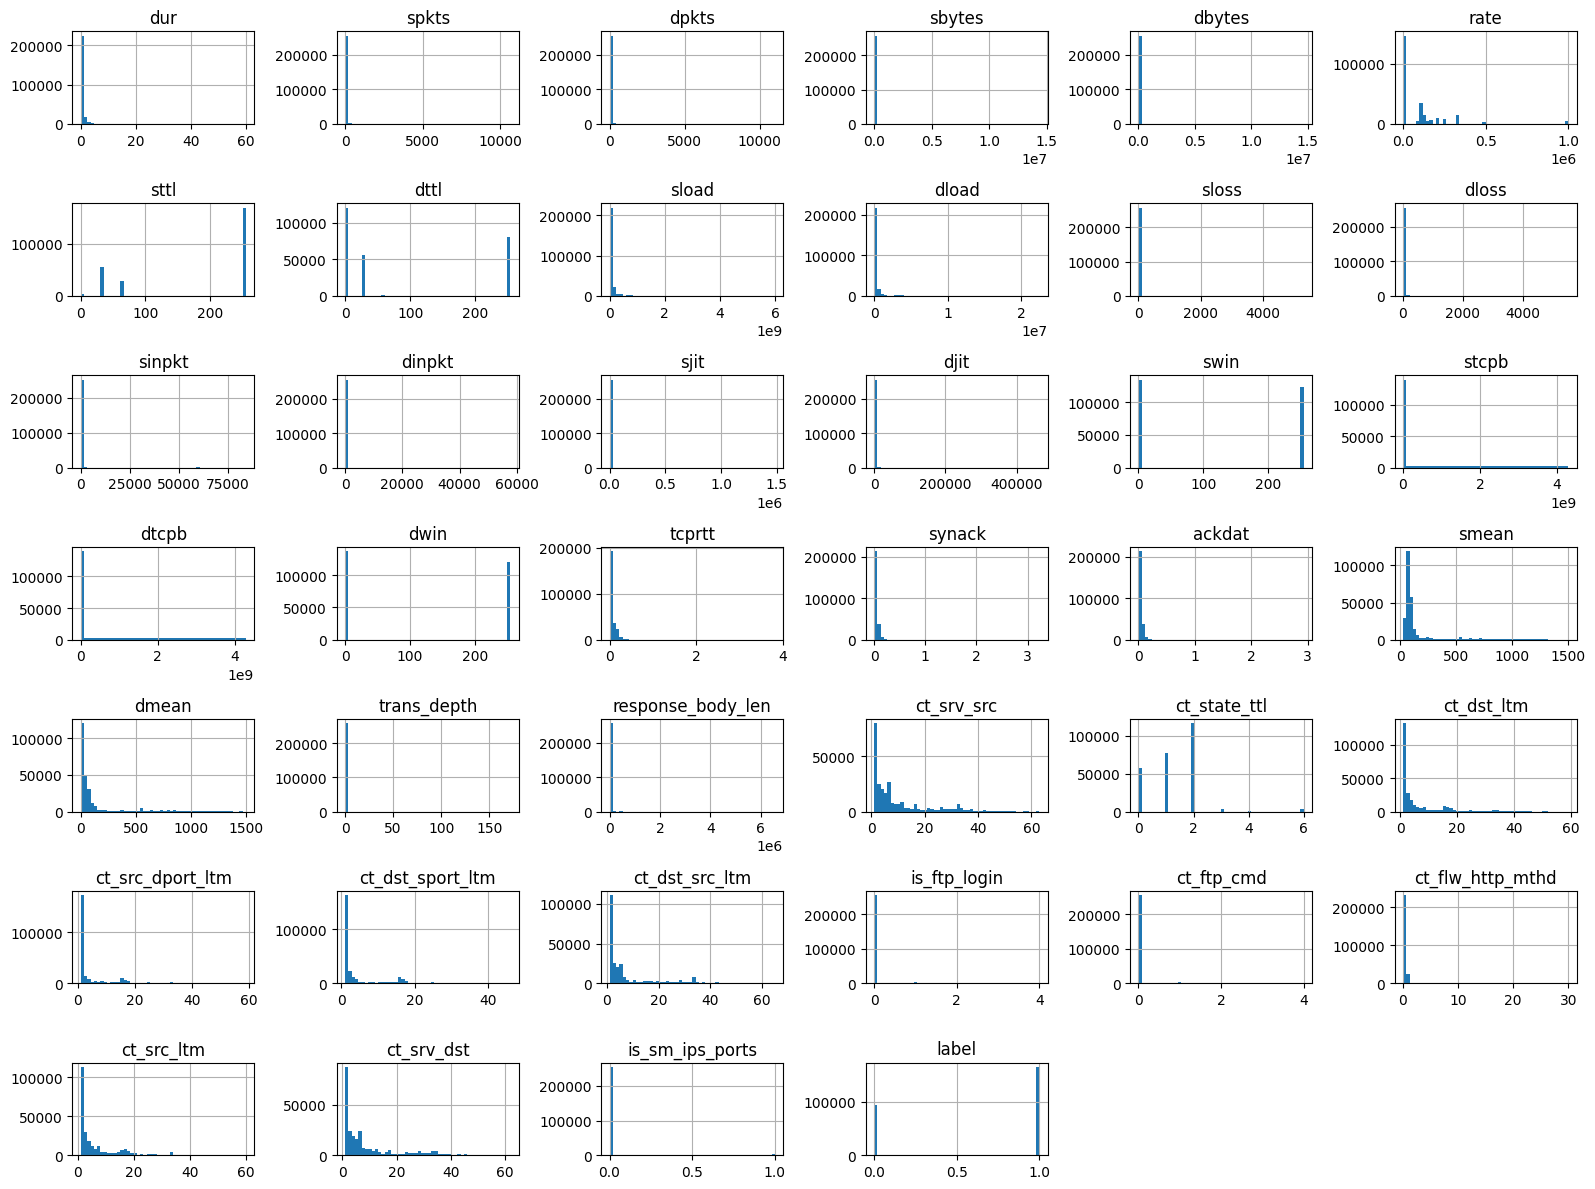

In [13]:
df_clean.hist(bins=50,figsize=(16, 12))

plt.tight_layout()
plt.show()

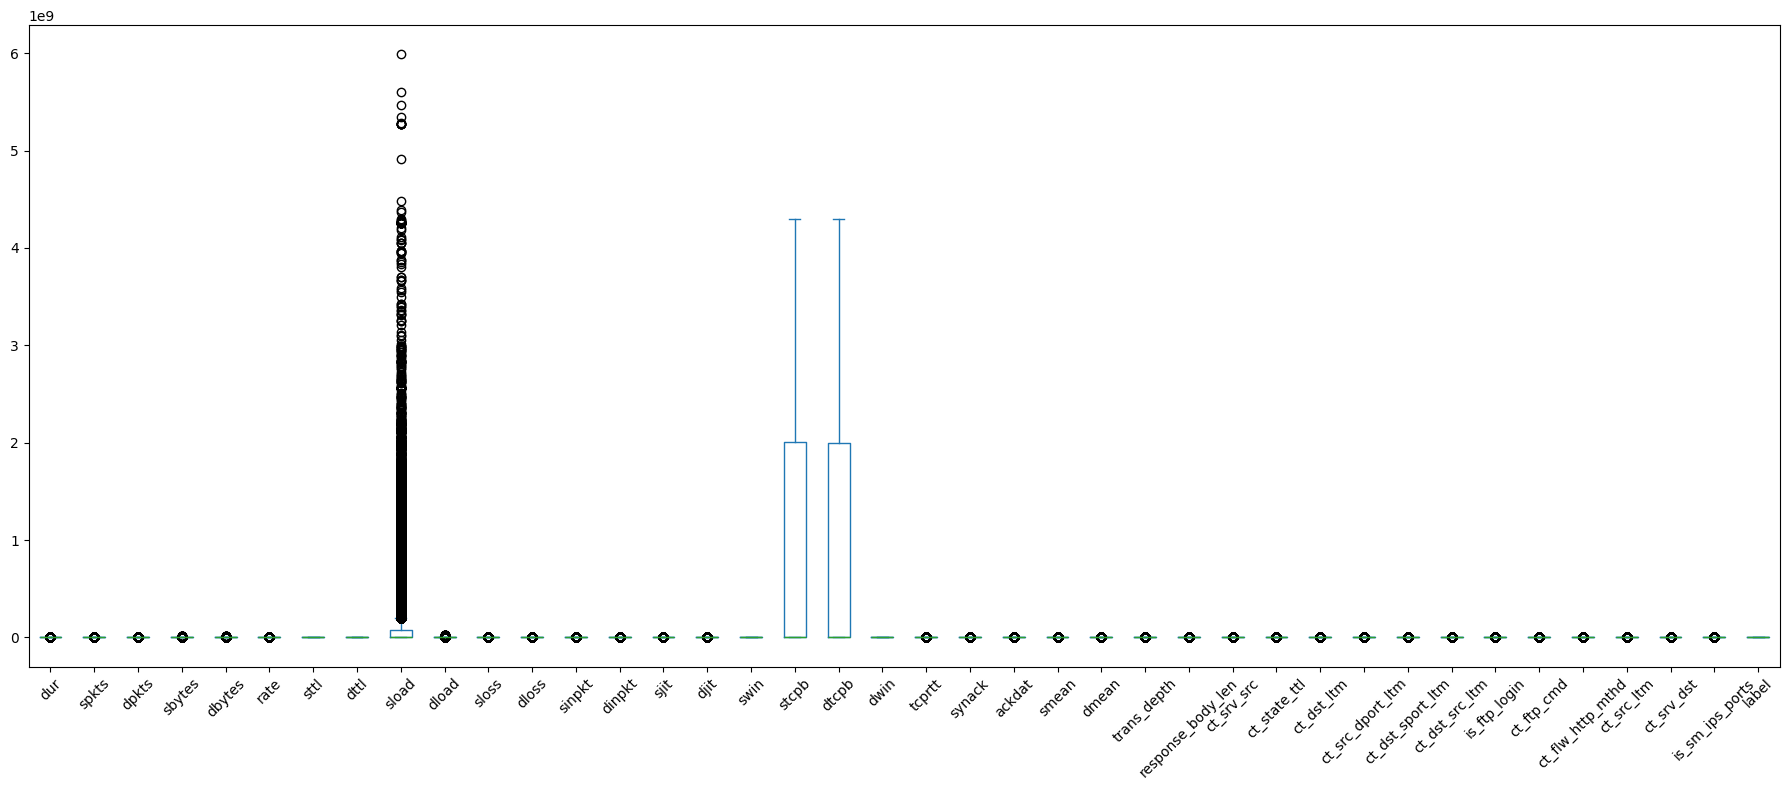

In [14]:
df_clean.plot(kind='box',figsize=(18, 8))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

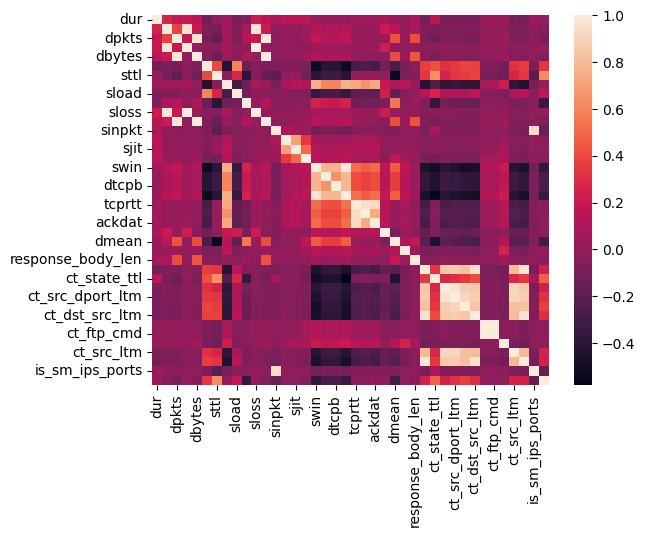

In [15]:
corr_table = df_clean.corr(numeric_only=True)
sns.heatmap(corr_table);

sttl                0.624082
ct_state_ttl        0.476559
ct_dst_sport_ltm    0.371672
Name: label, dtype: float64
swin    -0.364877
dload   -0.352169
dwin    -0.339166
Name: label, dtype: float64


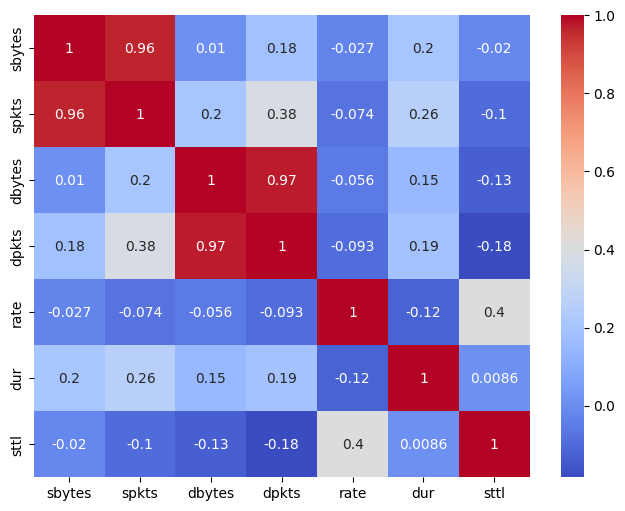

In [17]:
active_df = df_clean
corr = active_df.corr(numeric_only=True)

top = corr['label'].sort_values(ascending=False)[1:4]
bottom = corr['label'].sort_values()[:3]

print(top)
print(bottom)

plt.figure(figsize=(8,6))
sns.heatmap(
    active_df[['sbytes','spkts','dbytes','dpkts','rate','dur','sttl']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

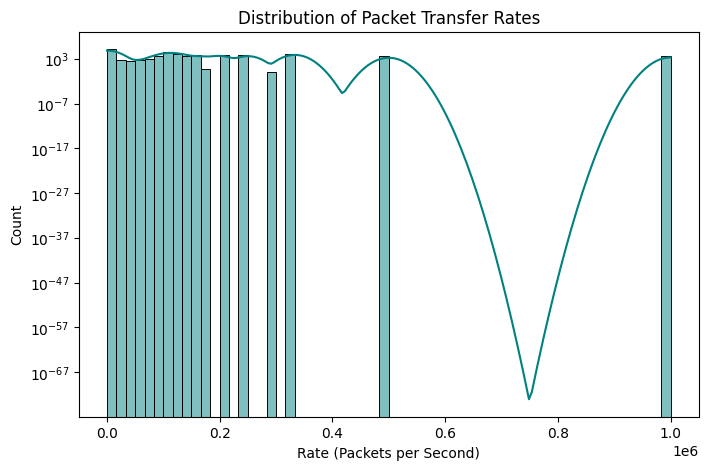

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['rate'], bins=60, kde=True, color='teal')
plt.title('Distribution of Packet Transfer Rates')
plt.xlabel('Rate (Packets per Second)')
plt.yscale('log')
plt.show()

C:\Users\fwx1294498\AppData\Local\Temp\ipykernel_5024\1356682218.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='label', palette='Set2')


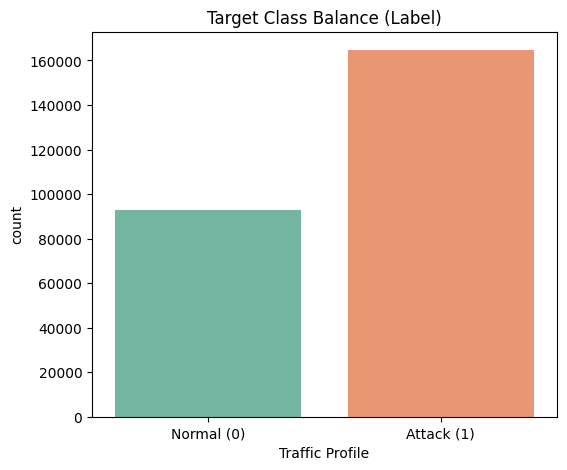

In [18]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df_clean, x='label', palette='Set2')
plt.title('Target Class Balance (Label)')
plt.xticks([0, 1], ['Normal (0)', 'Attack (1)'])
plt.xlabel('Traffic Profile')
plt.show()

C:\Users\fwx1294498\AppData\Local\Temp\ipykernel_14164\3947191752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label',y='sttl',data=df_clean,palette='pastel')


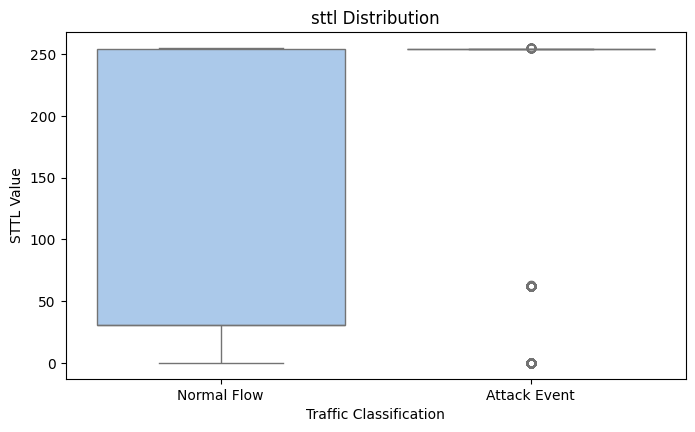

In [31]:
plt.figure(figsize=(8, 4.5))

sns.boxplot(x='label',y='sttl',data=df_clean,palette='pastel')

plt.title('sttl Distribution')
plt.xticks([0, 1], ['Normal Flow', 'Attack Event'])
plt.xlabel('Traffic Classification')
plt.ylabel('STTL Value')

plt.show()

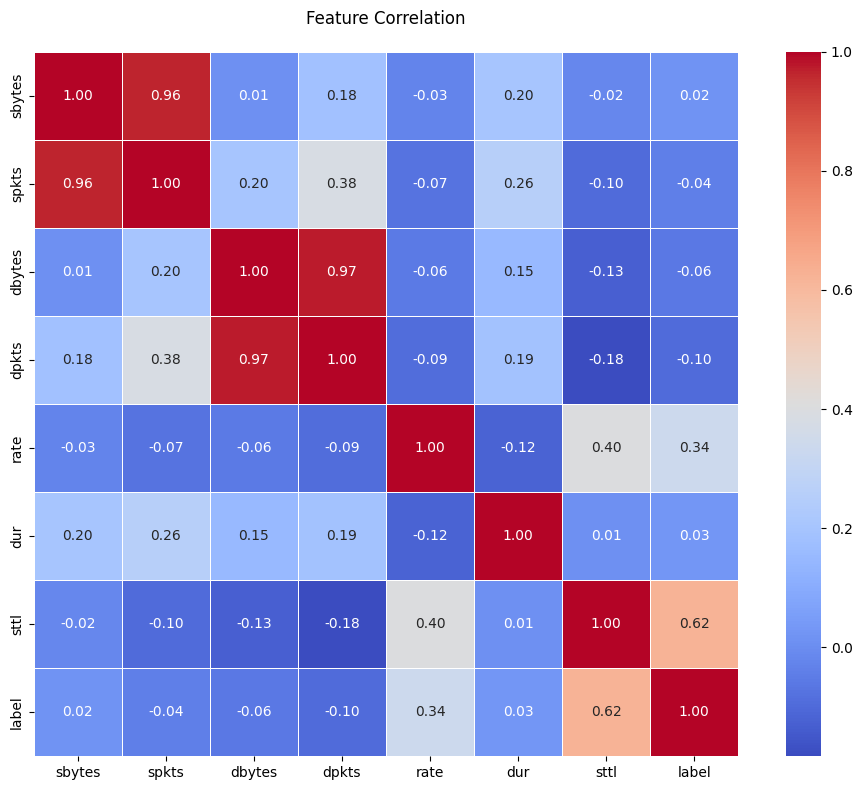

In [32]:
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

flow_metrics = ['sbytes', 'spkts', 'dbytes', 'dpkts', 'rate', 'dur', 'sttl', 'label']

existing_metrics = [m for m in flow_metrics if m in df_clean.columns]

corr_matrix = df_clean[existing_metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5,square=True)

plt.title('Feature Correlation', pad=20)
plt.tight_layout()
plt.show()

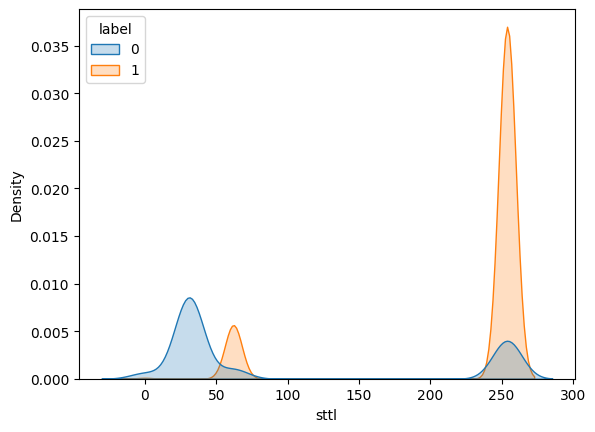

In [33]:
sns.kdeplot(data=df, x='sttl', hue='label', fill=True)
plt.show()

C:\Users\fwx1294498\AppData\Local\Temp\ipykernel_14164\3132932887.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='sttl', hue='attack_cat', fill=True)


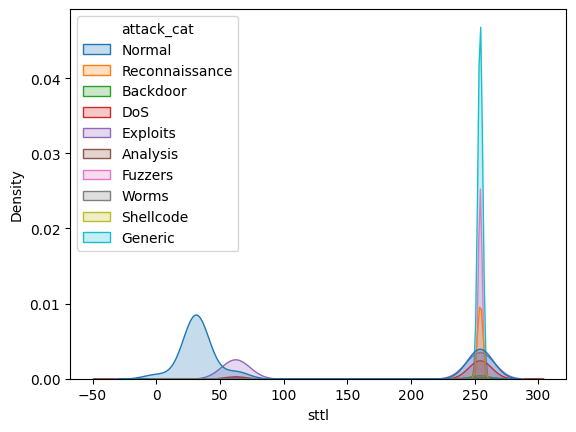

In [34]:
sns.kdeplot(data=df, x='sttl', hue='attack_cat', fill=True)
plt.show()

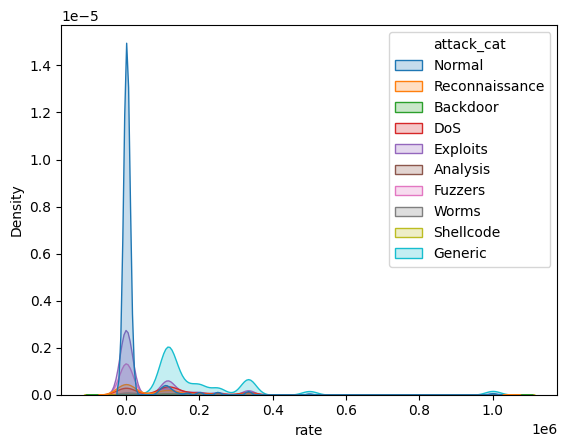

In [35]:
sns.kdeplot(data=df, x='rate', hue='attack_cat', fill=True)
plt.show()

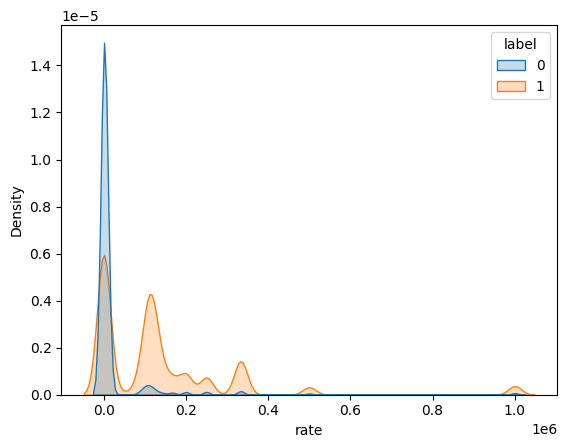

In [25]:
sns.kdeplot(data=df, x='rate', hue='label', fill=True)
plt.show()

In [28]:
summary = df_clean.groupby('label')['sttl'].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
])
print (summary)

        count        mean  median         std  min  max
label                                                  
0       93000   94.890075    31.0  100.402926    0  255
1      164673  228.067765   254.0   65.889193    0  255


In [30]:
summary2 = df_clean.groupby('attack_cat')['rate'].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
])
print (summary2)

                count           mean         median            std       min  \
attack_cat                                                                     
Analysis         2677  147808.321331  111111.107200  175887.777892  0.000000   
Backdoor         2329  149210.049223  111111.107200  171459.341229  0.000000   
DoS             16353  146165.897023  111111.107200  179734.497641  0.000000   
Exploits        44525   67962.710152      57.064596  143588.602967  0.000000   
Fuzzers         24246   67276.151116      33.898213  142342.560441  0.000000   
Generic         58871  209833.200813  125000.000300  185445.357803  0.000000   
Normal          93000   19588.290163     642.325743   83966.069810  0.000000   
Reconnaissance  13987   99718.726485      75.678455  169713.144343  0.000000   
Shellcode        1511   99145.578133   31250.000080  165115.888184  1.292354   
Worms             174   20873.619227      44.633688   66920.835462  1.070035   

                         max  
attack_c

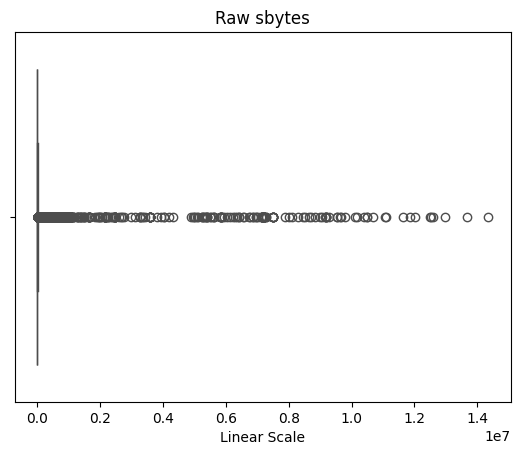

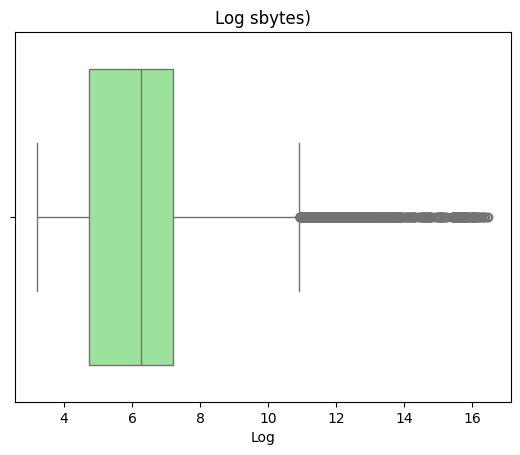

In [36]:
# Raw boxplot
sns.boxplot(x=df_clean['sbytes'], color='grey')
plt.title('Raw sbytes')
plt.xlabel('Linear Scale')
plt.show()

# Log-transformed boxplot 
sbytes_log = np.log1p(df_clean['sbytes'])
sns.boxplot(x=sbytes_log, color='lightgreen')
plt.title('Log sbytes)')
plt.xlabel('Log')
plt.show()

# Data Preprocessing & Feature Engineering
Transforming, encoding, standardization and preparing features
- **You only need to outline your approach here. No need to execute**

Apply One-Hot Encoding to string columns like state, service and proto.

Use StandardScaler on continuous values to normalize standard packet counts

Log-Transformation to handle outliers

Create customized proportional traffic rates:
-Packet Symmetry Ratio
-Byte Density Value

# Modelling Approach
What are the models you are planning to build for your capstone.
- **You only need to outline your approach here. No need to execute**

-KNN
-Logistic Regression
-XGBOOSt